# Claim Damage Detector — Notebook de Demonstração

Este notebook é apenas para exploração interativa. A implementação de verdade vive em `src/` (veja o README para detalhes e limitações do escopo). Para treinar de fato, prefira os scripts CLI:

```bash
python -m src.train_classifier --epochs 25
python -m src.train_gan --epochs 50
python -m src.predict caminho/imagem.jpg
```

Para a análise exploratória dos dados (EDA), veja `notebooks/01_exploratory_analysis.ipynb`.

In [1]:
# O notebook mora em notebooks/, mas o pacote `src/` está um nível acima
# (na raiz do projeto) -- por isso é preciso adicionar ".." ao sys.path para
# o `import src...` funcionar aqui dentro.
import sys
sys.path.append("..") if "src" not in sys.path else None

import matplotlib.pyplot as plt

# Reaproveita exatamente o mesmo código usado pelos scripts CLI (src/train_classifier.py) --
# não há lógica duplicada aqui, só chamadas às funções de src/.
from src.data import load_classifier_dataset
from src.classifier import build_classifier

Found 1840 files belonging to 2 classes.


Found 460 files belonging to 2 classes.


Classes: ['00-damage', '01-whole']


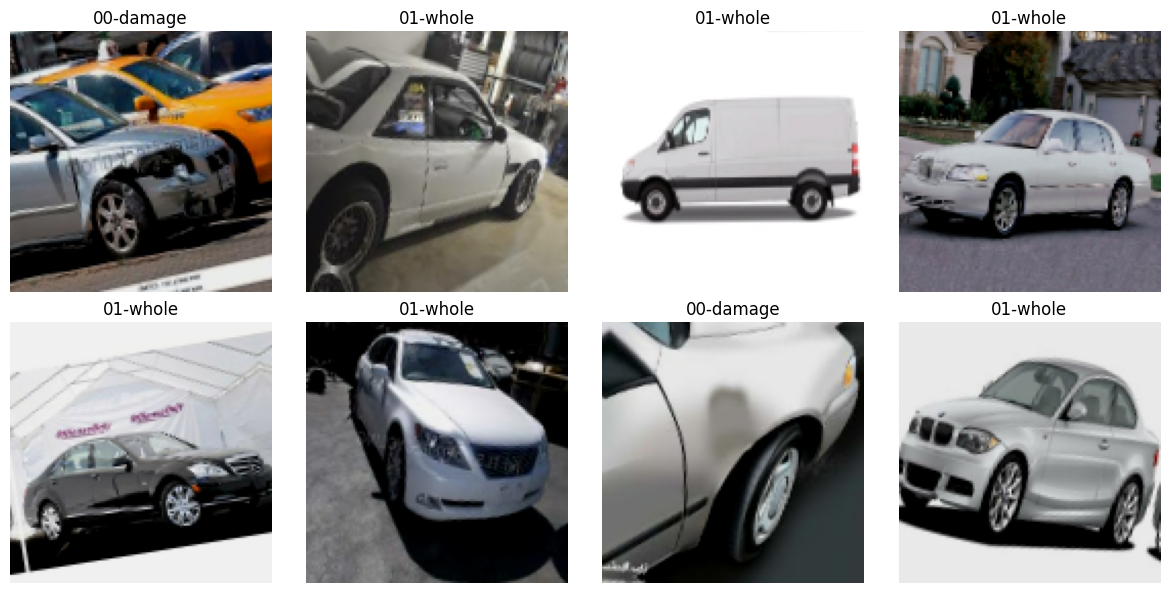

In [2]:
# Requer o dataset baixado (veja README: "Baixar o dataset").
# load_classifier_dataset() já devolve os dados prontos para treino: divididos
# em treino/validação, redimensionados, normalizados para [0,1] e com
# augmentation aplicada no split de treino (ver src/data.py).
train_ds, val_ds, class_names = load_classifier_dataset()
print("Classes:", class_names)

# Pega só o primeiro batch para visualizar algumas imagens de exemplo já como
# o modelo as "enxerga" (redimensionadas, com augmentation aleatória aplicada).
images, labels = next(iter(train_ds))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, image, label in zip(axes.ravel(), images, labels):
    ax.imshow(image.numpy())
    ax.set_title(class_names[int(label.numpy()[0])])
    ax.axis("off")
plt.tight_layout()

In [3]:
# Treino rápido para exploração (poucas épocas, sem class_weight nem
# EarlyStopping -- por isso os números aqui tendem a ser piores que o
# resultado de referência do README, que usa `python -m src.train_classifier
# --epochs 25`). O objetivo deste notebook é ver o modelo treinando ao vivo,
# não obter o melhor modelo possível.
model = build_classifier()
history = model.fit(train_ds, validation_data=val_ds, epochs=2)

Epoch 1/2


 1/58 ━━━━━━━━━━━━━━━━━━━━ 6:05 6s/step - accuracy: 0.5000 - loss: 0.8237

 2/58 ━━━━━━━━━━━━━━━━━━━━ 13s 242ms/step - accuracy: 0.5078 - loss: 0.8105

 3/58 ━━━━━━━━━━━━━━━━━━━━ 11s 208ms/step - accuracy: 0.5156 - loss: 0.8114

 4/58 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.5234 - loss: 0.8096

...

55/58 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7338 - loss: 0.5263

56/58 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7343 - loss: 0.5259

57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.7348 - loss: 0.5255

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7352 - loss: 0.5250

58/58 ━━━━━━━━━━━━━━━━━━━━ 13s 218ms/step - accuracy: 0.7620 - loss: 0.5013 - val_accuracy: 0.6652 - val_loss: 0.6117


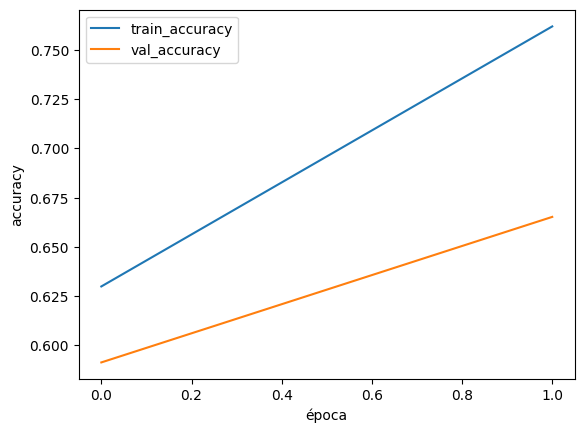

In [4]:
# `history.history` é um dicionário com uma lista de valores por métrica,
# um valor por época -- é o que o Keras usa internamente para os gráficos
# de accuracy/loss que aparecem no README (docs/results/training_history.png,
# gerados via save_history_plot() em src/train_classifier.py).
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("época")
plt.ylabel("accuracy")
plt.legend()
plt.show()